<a href="https://colab.research.google.com/github/ShikhaChauhan20/Heart-Disease-Prediction-ML/blob/main/Ad_Click_Prediction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd # Import pandas for data manipulation
import numpy as np # Import numpy for numerical operations

from sklearn.model_selection import train_test_split # Import for splitting data
from sklearn.linear_model import LogisticRegression # Import the Logistic Regression model
from sklearn.preprocessing import StandardScaler # Import for feature scaling
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # Import evaluation metrics

import matplotlib.pyplot as plt # Import for basic plotting
import seaborn as sns

sns.set_style('whitegrid')

In [2]:

df = pd.read_csv('advertising.csv') # Load the dataset from the uploaded file
print("Dataset loaded successfully.")


df_clean = df.drop(['Ad Topic Line', 'City', 'Country', 'Timestamp'], axis=1)

# Separate features (X) and target (y)
X = df_clean.drop('Clicked on Ad', axis=1) # Features are all columns except target
y = df_clean['Clicked on Ad'] # Target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Split data 70/30


scaler = StandardScaler() # Initialize the standard scaler
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data prepared and scaled with {X.shape[1]} features.")

FileNotFoundError: [Errno 2] No such file or directory: 'advertising.csv'

In [ ]:
# --- A. Model Training ---
logmodel = LogisticRegression(solver='liblinear', random_state=42) # Initialize Logistic Regression model
logmodel.fit(X_train_scaled, y_train)

predictions = logmodel.predict(X_test_scaled) # Generate binary predictions (0 or 1)

# --- B. Model Evaluation ---
print("\n--- 1. Confusion Matrix ---")
print(confusion_matrix(y_test, predictions))

print("\n--- 2. Classification Report (Precision/Recall) ---")
print(classification_report(y_test, predictions))

accuracy = accuracy_score(y_test, predictions)
print(f"\n--- 3. Overall Accuracy ---\nTest Set Accuracy: {accuracy:.4f}")

# --- C. Feature Importance (Coefficients) ---
print("\n--- 4. Feature Coefficients for Business Insight ---")

feature_names = X.columns
coefficients = logmodel.coef_[0]

feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
feature_importance['Absolute_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False).drop('Absolute_Coefficient', axis=1)

print("\nCoefficients of Scaled Features:")
print(feature_importance)


Visualization saved as 'feature_scatter.png'.


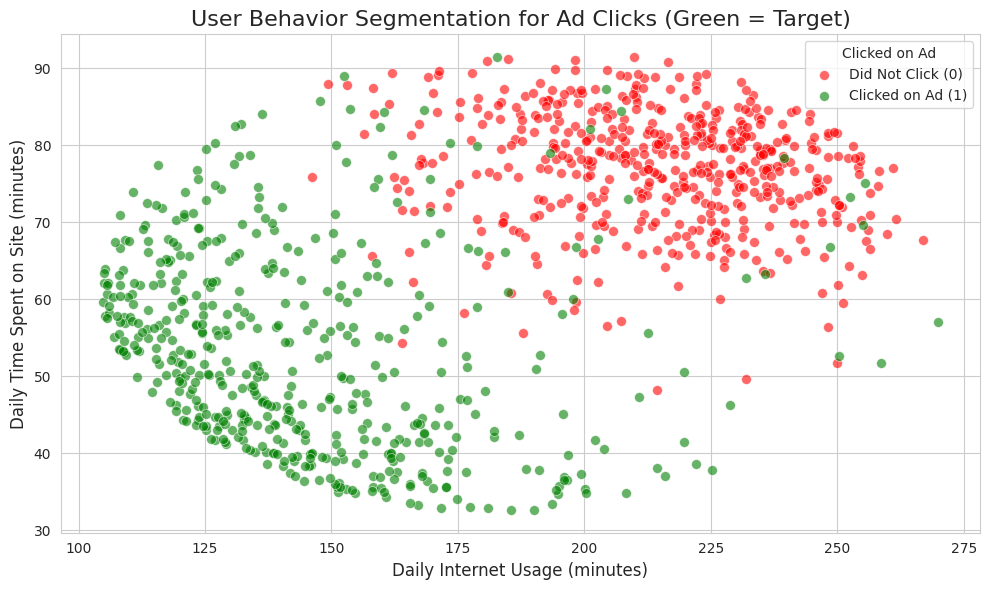

In [ ]:
# --- A. Visualize Key Feature Relationship ---
plt.figure(figsize=(10, 6))

# Scatter plot for users who Did Not Click (0)
sns.scatterplot(x='Daily Internet Usage', y='Daily Time Spent on Site', data=df_clean[df_clean['Clicked on Ad'] == 0], color='red', label='Did Not Click (0)', alpha=0.6, s=50)

# Scatter plot for users who Clicked on Ad (1)
sns.scatterplot(x='Daily Internet Usage', y='Daily Time Spent on Site', data=df_clean[df_clean['Clicked on Ad'] == 1], color='green', label='Clicked on Ad (1)', alpha=0.6, s=50)

plt.title('User Behavior Segmentation for Ad Clicks (Green = Target)', fontsize=16)
plt.xlabel('Daily Internet Usage (minutes)', fontsize=12)
plt.ylabel('Daily Time Spent on Site (minutes)', fontsize=12)
plt.legend(title='Clicked on Ad', fontsize=10)
plt.tight_layout()

plt.savefig('feature_scatter.png')
print("\nVisualization saved as 'feature_scatter.png'.")